# D2. 디지털 오디오 기초: 소리는 어떻게 숫자가 될까

**음성 AI 전문가 과정 (160h) | 1주차 M1 | 4시간**

## 학습 목표
1. 소리의 높낮이(주파수)와 크기(진폭)를 구분하고 직접 만들어 들어 본다.
2. 샘플링 레이트, 비트 깊이, 채널이 소리에 어떤 영향을 주는지 귀와 눈으로 확인한다.
3. WAV, FLAC, MP3, Opus의 차이를 파일 크기와 음질로 비교한다.
4. librosa, soundfile, pydub, ffmpeg의 역할을 구분하고, 어떤 파일이든 **16kHz mono WAV**로 바꾸는 전처리기를 만든다.
5. 사인파, 샘플링 정리, Aliasing, 양자화 잡음, 비트레이트, 데시벨을 **수식으로 설명하고 코드로 검증**한다.

## 오늘의 실습 흐름
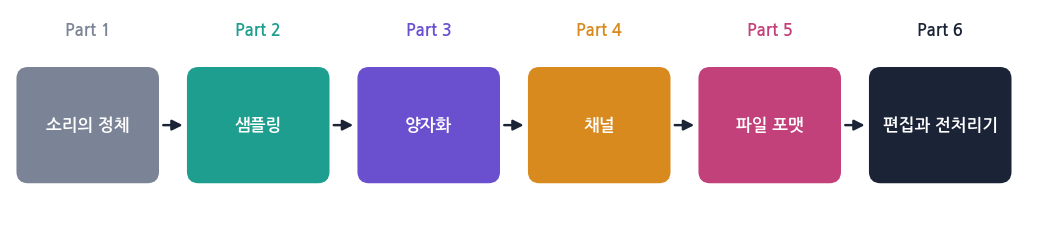

| 교시 | 내용 | 실습 |
|---|---|---|
| 1교시 | 소리의 정체, 샘플링 | Part 1 ~ 2, 워크시트 1교시 |
| 2교시 | 양자화, 채널 | Part 3 ~ 4, 워크시트 2교시 |
| 3교시 | 파일 포맷 비교 | Part 5, 워크시트 3교시 |
| 4교시 | pydub 편집, 전처리기 만들기 | Part 6 ~ 7, 워크시트 4교시 · 노션 제출 |

## 오늘의 수업 자료
| 자료 | 링크 | 언제 쓰나요 |
|---|---|---|
| 🎬 인터랙티브 애니메이션 | [animation.html](https://imguru-mooc.github.io/AI_Voice/day02/animation.html) | 각 Part 설명을 볼 때 (Part마다 바로가기 링크가 있습니다) |
| 📝 개념 워크시트 | [worksheet.html](https://imguru-mooc.github.io/AI_Voice/day02/worksheet.html) | 각 교시 끝에 해당 탭 10문항 (4교시 × 10문항), 오답 캡처 → 노션 |

## 이 노트북 사용법
- ▶️ 일반 코드 셀은 위에서부터 차례로 실행합니다.
- 🧩 **빈칸 실습** 셀은 `____`(밑줄 4개)를 지우고 알맞은 값을 채운 뒤 실행합니다. 마지막 줄에서 ✅ 또는 ❌로 결과를 알려줍니다.
- 🔑 **정답 및 해설 보기**를 클릭하면 정답이 펼쳐집니다. 먼저 스스로 풀어 보세요.
- 🎧 오늘은 **소리를 듣는 실습**이 많습니다. 이어폰을 준비하세요.
- 📐 각 Part의 **수식으로 보기** 절에서 원리를 수식으로 정리하고, ▶️ **수식 검증** 셀에서 수식의 예측값과 실제 측정값을 비교합니다.

> ⚙️ 오늘은 GPU가 필요 없습니다. 기본 CPU 런타임으로 충분합니다.

> 🎬 **애니메이션 D2-1:** [오늘의 흐름](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#flow) — Part 1~6 로드맵

## Part 0. 준비

필요한 라이브러리를 설치하고, 오늘 계속 쓸 도우미 함수를 만듭니다.

- `pydub`은 Python 3.13에서 빠진 `audioop` 모듈이 필요해서 `audioop-lts`를 함께 설치합니다.

In [ ]:
!pip install -q edge-tts pydub "audioop-lts; python_version >= '3.13'" librosa soundfile
print("✅ 설치 완료")

In [ ]:
import os, subprocess
import numpy as np
import librosa, librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display

SR = 16000   # 음성 모델의 표준 샘플링 레이트

def ffmpeg(*args):
    # ffmpeg 명령 실행 도우미 (오류 메시지는 숨김)
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", *args], check=True)

def size_kb(path):
    return os.path.getsize(path) / 1024

def check(cond, hint="빈칸을 다시 확인하세요."):
    print("✅ 정답입니다! 🎉" if cond else f"❌ {hint}")

print("🧩 준비 완료")

#### 🔍 코드 해설: 준비 셀

| 코드 | 하는 일 |
|---|---|
| `SR = 16000` | 오늘 계속 쓸 기준 샘플링 레이트. 숫자를 여기저기 쓰지 않고 이름으로 쓰면 바꾸기 쉽습니다 |
| `subprocess.run(["ffmpeg", "-y", "-loglevel", "error", *args], check=True)` | 터미널 명령 ffmpeg를 파이썬에서 실행. `-y` 덮어쓰기 허용, `-loglevel error` 잡다한 출력 숨김, `check=True` 실패하면 바로 오류 |
| `*args` | 받은 인자를 그대로 펼쳐 붙임. `ffmpeg("-i", "a.mp3", "b.wav")` → `ffmpeg -y -loglevel error -i a.mp3 b.wav` |
| `os.path.getsize(path) / 1024` | 파일 크기(바이트)를 KB로. $1\,\text{KB} = 1024$ 바이트 |

### 0-1. 오늘 쓸 음성 만들기
D1에서 쓴 edge-tts로 한국어 음성을 만듭니다. 이번에는 일부러 **44.1kHz stereo** 고음질 파일도 함께 만들어, 오늘 내내 "큰 파일을 음성 모델용으로 줄이는" 연습에 씁니다.

In [ ]:
import edge_tts

TEXT = "안녕하세요. 오늘은 소리가 어떻게 숫자가 되는지 배웁니다. 샘플링과 양자화, 그리고 오디오 파일 포맷을 직접 비교해 봅니다."
await edge_tts.Communicate(TEXT, "ko-KR-SunHiNeural").save("speech.mp3")

ffmpeg("-i", "speech.mp3", "-ar", "44100", "-ac", "2", "speech_hq.wav")   # 44.1kHz stereo 고음질
ffmpeg("-i", "speech.mp3", "-ar", "16000", "-ac", "1", "speech.wav")      # 16kHz mono (D1 표준)

for f in ["speech.mp3", "speech_hq.wav", "speech.wav"]:
    info = sf.info(f)
    print(f"{f:15s} {info.samplerate:>6} Hz | {info.channels}ch | {info.duration:.2f}초 | {size_kb(f):8.1f} KB")
display(Audio("speech.wav"))

#### 🔍 코드 해설: 음성 만들기

| 코드 | 하는 일 |
|---|---|
| `edge_tts.Communicate(TEXT, voice).save("speech.mp3")` | 인터넷 TTS로 문장을 합성해 mp3로 저장 (24kHz mono). 네트워크 작업이라 `await` |
| `"-ar", "44100", "-ac", "2"` | `-ar` audio rate(샘플링 레이트), `-ac` audio channels(채널 수). 44.1kHz stereo로 **일부러 크게** 만듦 |
| `"-ar", "16000", "-ac", "1"` | 음성 모델 표준인 16kHz mono로 변환 |
| `sf.info(f)` | 파일을 다 읽지 않고 머리말(헤더)만 읽어 샘플링 레이트, 채널, 길이를 알려 줌. 아주 빠름 |

> 💡 44.1kHz stereo 파일은 mp3(24kHz mono)보다 정보가 많아진 것이 아닙니다. 원본에 없던 높은 소리가 생기지는 않고, 숫자만 늘어납니다. 크기 비교와 변환 연습용입니다.

## Part 1. 소리의 정체: 공기의 떨림이 숫자가 되기까지

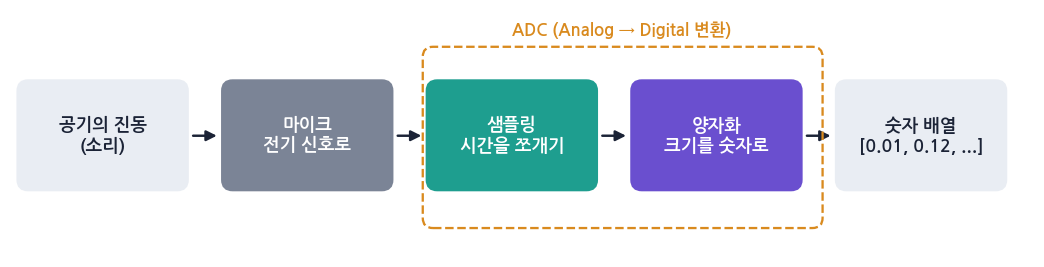

마이크는 공기의 떨림을 전기 신호로 바꾸고, 컴퓨터는 그 신호를 **일정한 간격으로 측정(샘플링)**해서 **숫자로 기록(양자화)**합니다. 그래서 컴퓨터 안의 소리는 결국 **숫자 배열**입니다.

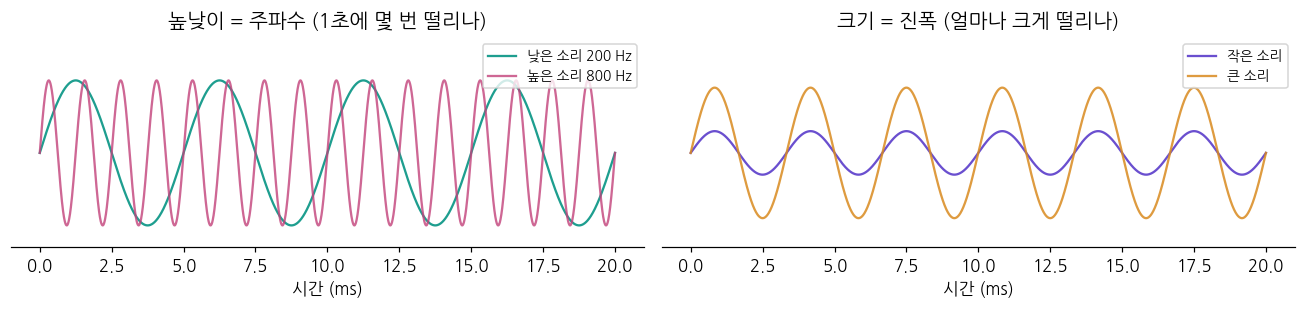

| 성질 | 뜻 | 귀로 느끼는 것 |
|---|---|---|
| **주파수** (Hz) | 1초에 몇 번 떨리는가 | 높낮이: 많이 떨릴수록 높은 소리 |
| **진폭** | 얼마나 크게 떨리는가 | 크기: 크게 떨릴수록 큰 소리 |

> 🎬 **애니메이션 D2-2:** [소리의 정체](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#sound) — 주파수와 크기를 슬라이더로 바꿔 직접 듣기

In [ ]:
def tone(freq, sec=1.0, sr=SR, amp=0.5):
    # freq Hz의 순수한 소리(사인파)를 숫자 배열로 만든다
    t = np.arange(int(sr * sec)) / sr
    return (amp * np.sin(2 * np.pi * freq * t)).astype(np.float32)

for f in [220, 440, 880]:
    print(f"{f} Hz")
    display(Audio(tone(f), rate=SR))

#### 🔍 코드 해설: tone() 함수

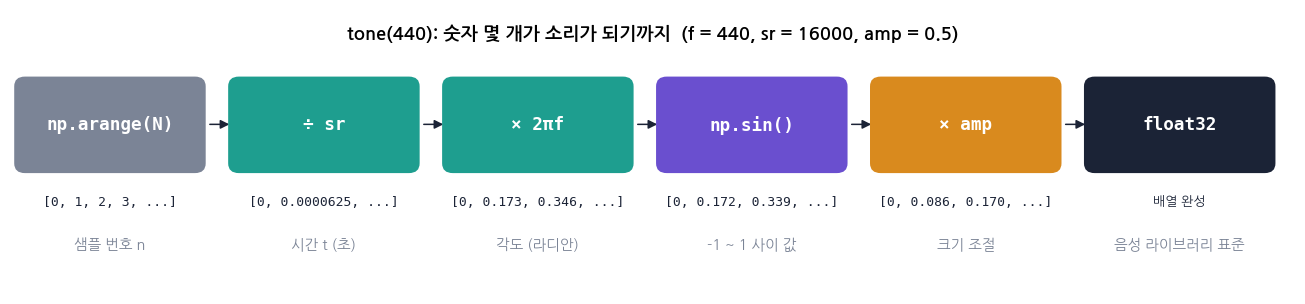

| 코드 | 하는 일 |
|---|---|
| `t = np.arange(int(sr * sec)) / sr` | 샘플 번호 $n = 0, 1, \dots, N-1$을 만들고 $f_s$로 나눠 시간 $t = n/f_s$로 바꿈. $N = f_s \times T$ |
| `2 * np.pi * freq * t` | 각도 $2\pi f t$. 1초에 $f$바퀴 도는 각도 |
| `amp * np.sin(...)` | $A\sin(2\pi f t)$. 결과는 $[-A, A]$ 사이 값 |
| `.astype(np.float32)` | 32bit 소수로 저장. librosa, soundfile이 쓰는 표준 자료형이고 float64보다 메모리 절반 |
| `Audio(tone(f), rate=SR)` | 숫자 배열을 노트북에서 재생. `rate`를 꼭 알려줘야 몇 초짜리 소리인지 알 수 있음 |

In [ ]:
# 같은 440 Hz, 크기만 다르게 (normalize=False: 원래 크기 그대로 재생)
for amp in [0.05, 0.2, 0.8]:
    print(f"진폭 {amp}")
    display(Audio(tone(440, amp=amp), rate=SR, normalize=False))

#### 🔍 코드 해설: normalize=False

| 코드 | 하는 일 |
|---|---|
| `Audio(..., normalize=True)  # 기본값` | 가장 큰 값을 1로 맞춰 재생. 진폭을 바꿔도 **모두 같은 크기로** 들림 |
| `Audio(..., normalize=False)` | 배열 값을 그대로 재생. 단, 값이 $[-1, 1]$을 넘으면 오류가 나므로 진폭은 1 이하로 |

In [ ]:
# 숫자 배열의 정체를 눈으로 확인
y = tone(220, sec=0.02)
print("모양:", y.shape, "| 자료형:", y.dtype)
print("처음 8개 숫자:", np.round(y[:8], 3))

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(np.arange(len(y)) / SR * 1000, y, "o-", ms=3)
ax.set_xlabel("time (ms)"); ax.set_title("220 Hz tone = array of numbers")
plt.tight_layout(); plt.show()

### 1-1. 📐 수식으로 보기: 사인파와 데시벨

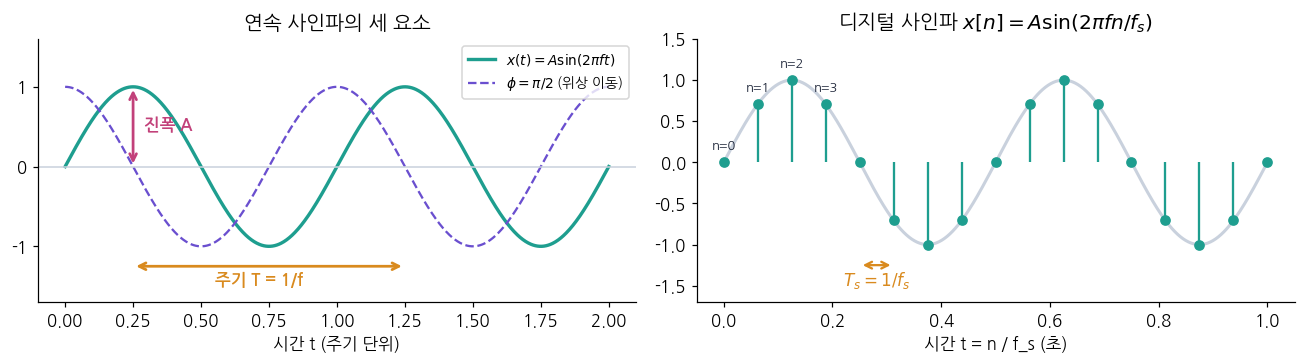

**연속 시간의 사인파**: 진폭 $A$, 주파수 $f$, 위상 $\phi$

$$
x(t) = A \sin(2\pi f t + \phi), \qquad \text{주기 } T = \frac{1}{f}
$$

**디지털 사인파**: 시간 $t$ 대신 샘플 번호 $n$을 쓰고, $t = n / f_s$를 대입합니다. `tone()` 함수가 바로 이 식입니다.

$$
x[n] = A \sin\!\left(2\pi \frac{f}{f_s} n\right), \qquad n = 0, 1, 2, \dots
$$

**옥타브**: 주파수가 2배가 되면 한 옥타브 높아집니다. $440\,\text{Hz} \times 2 = 880\,\text{Hz}$

**데시벨(dB)**: 사람은 크기를 비율(로그)로 느낍니다. 진폭 $A_1$을 기준 $A_0$와 비교하면

$$
L = 20 \log_{10}\!\left(\frac{A_1}{A_0}\right) \ \text{dB}
$$

| 진폭 비율 | dB |
|---|---|
| 2배 | $20\log_{10}2 \approx +6.02$ dB |
| 4배 | $\approx +12.04$ dB |
| 1/10 | $-20$ dB |

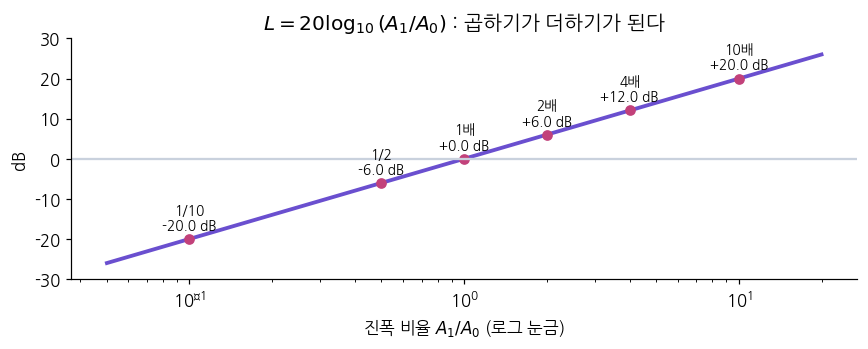

데시벨은 **곱하기를 더하기로** 바꿉니다. 2배(+6 dB)를 두 번 하면 4배(+12 dB)입니다. 그래서 사람의 귀처럼 아주 작은 소리부터 아주 큰 소리까지 한 눈금으로 다룰 수 있습니다.

**RMS (평균 세기)**: 사인파의 RMS는 진폭의 $1/\sqrt{2}$입니다. $\;\text{RMS} = A / \sqrt{2} \approx 0.707A$

> 🎬 **애니메이션 D2-2:** [소리의 정체](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#sound) — 슬라이더를 움직이면 아래 수식 줄에 x[n], 주기 T, dB 값이 바로 계산됩니다

In [ ]:
# ▶️ 수식 검증 1: 주기, dB, RMS
for f in [220, 440, 880]:
    print(f"{f:4d} Hz → 주기 T = 1/f = {1000 / f:.3f} ms, 1주기당 샘플 수 = f_s/f = {SR / f:.1f}개")

print()
for a1, a0 in [(0.2, 0.05), (0.8, 0.2), (0.8, 0.05)]:
    print(f"진폭 {a1} vs {a0}: 20·log10({a1}/{a0}) = {20 * np.log10(a1 / a0):+.2f} dB")

y = tone(440, amp=0.8)
print(f"\nRMS 측정 = {np.sqrt(np.mean(y**2)):.4f} | 이론 A/√2 = {0.8 / np.sqrt(2):.4f}")

### 🧩 빈칸 실습 1: 높은 "라" 소리 만들기
위 `tone()` 함수로 **880 Hz** 소리를 만들어 들어 보세요. 아래 셀은 만든 소리의 주파수를 자동으로 측정해 검사합니다.

In [ ]:
# 🧩 빈칸 실습 1
my_tone = tone(____)                 # 880 Hz 소리

display(Audio(my_tone, rate=SR))
peak_hz = np.argmax(np.abs(np.fft.rfft(my_tone))) * SR / len(my_tone)   # 가장 강한 주파수 측정
print(f"측정된 주파수: {peak_hz:.0f} Hz")
check(abs(peak_hz - 880) < 2, hint="tone() 안에 주파수 숫자를 넣으세요.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
my_tone = tone(880)
```

**해설**: `tone(880)`은 1초에 880번 떨리는 소리를 만듭니다. 440 Hz의 정확히 두 배라서 한 옥타브 높은 "라"로 들립니다. 사람의 말소리는 이런 여러 주파수가 섞여 있는 소리입니다.

</details>

## Part 2. 샘플링: 1초에 몇 번 측정할까

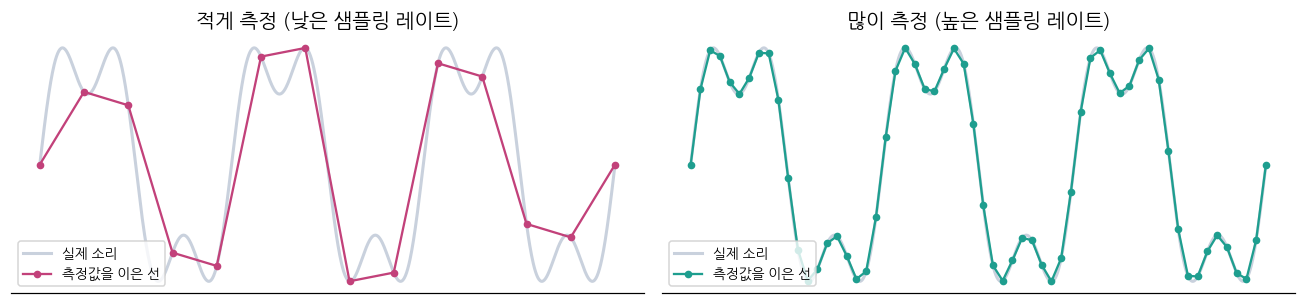

**샘플링 레이트**는 1초에 소리를 몇 번 측정하는지입니다. 많이 측정할수록 원래 모양에 가깝지만 숫자(파일)도 많아집니다.

| 샘플링 레이트 | 주로 쓰는 곳 | 담을 수 있는 가장 높은 소리 |
|---|---|---|
| 8,000 Hz | 옛날 전화 | 약 4,000 Hz |
| **16,000 Hz** | **음성 인식 (Whisper 등)** | 약 8,000 Hz |
| 44,100 Hz | 음악 CD | 약 22,000 Hz |
| 48,000 Hz | 영상, 방송 | 약 24,000 Hz |

> 💡 **핵심 규칙:** 샘플링 레이트의 **절반**까지의 높이만 담을 수 있습니다. 사람 말소리의 중요한 정보는 대부분 낮은 쪽에 있어서 16,000 Hz로 충분합니다.

> 🎬 **애니메이션 D2-3:** [샘플링 체험](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#sampling) — 측정 횟수를 바꾸며 모양과 소리 비교

In [ ]:
y44, sr44 = librosa.load("speech_hq.wav", sr=None)    # sr=None: 원래 샘플링 레이트 그대로
print(f"원본: {sr44} Hz, 샘플 {len(y44):,}개, {len(y44) / sr44:.2f}초")

for target in [16000, 8000]:
    y_new = librosa.resample(y44, orig_sr=sr44, target_sr=target)
    print(f"\n{target} Hz로 줄이기: 샘플 {len(y_new):,}개 ({len(y_new) / len(y44):.0%})")
    display(Audio(y_new, rate=target))

#### 🔍 코드 해설: 불러오기와 resample

| 코드 | 하는 일 |
|---|---|
| `librosa.load(path, sr=None)` | 원래 샘플링 레이트 그대로 불러옴. `sr`을 생략하면 기본값 **22,050 Hz로 자동 변환**되니 주의 |
| `y44, sr44 = ...` | librosa.load는 항상 (배열, 샘플링 레이트) 두 개를 돌려줌. mono=True가 기본이라 stereo도 합쳐짐 |
| `librosa.resample(y, orig_sr=..., target_sr=...)` | 필터로 높은 소리를 먼저 지우고 샘플 수를 $N \cdot f_{new}/f_{old}$로 바꿈 |
| `len(y_new) / len(y44)` | 샘플 수 비율 = $16000/44100 \approx 36\%$. 1초당 숫자가 그만큼 줄어듦 |

### 2-1. 함부로 줄이면 생기는 일: Aliasing
높아지는 소리(200 Hz → 7,000 Hz)를 준비해서, 두 가지 방법으로 샘플링 레이트를 4분의 1로 줄여 봅니다.

- **건너뛰기**: 숫자를 4개 중 1개만 남김 → 담을 수 없는 높은 소리가 **가짜 낮은 소리**로 바뀝니다 (Aliasing).
- **librosa.resample**: 담을 수 없는 높은 소리를 먼저 걸러낸 뒤 줄임 → 높은 부분이 조용해질 뿐 가짜 소리가 없습니다.

In [ ]:
chirp = librosa.chirp(fmin=200, fmax=7000, sr=44100, duration=3).astype(np.float32) * 0.5
skip  = chirp[::4]                                                     # 건너뛰기 (11,025 Hz)
good  = librosa.resample(chirp, orig_sr=44100, target_sr=11025)       # 제대로 줄이기

for name, y_, sr_ in [("원본 44,100 Hz", chirp, 44100), ("건너뛰기 11,025 Hz", skip, 11025), ("resample 11,025 Hz", good, 11025)]:
    print(name); display(Audio(y_, rate=sr_))

fig, axs = plt.subplots(1, 3, figsize=(14, 3))
for ax, (title, y_, sr_) in zip(axs, [("original", chirp, 44100), ("skip [::4]", skip, 11025), ("librosa.resample", good, 11025)]):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(y_, n_fft=1024)), ref=np.max)
    librosa.display.specshow(S, sr=sr_, hop_length=256, x_axis="time", y_axis="hz", ax=ax); ax.set_title(title); ax.set_ylim(0, 8000)
plt.tight_layout(); plt.show()

#### 🔍 코드 해설: Aliasing 실험

| 코드 | 하는 일 |
|---|---|
| `librosa.chirp(fmin=200, fmax=7000, sr=44100, duration=3)` | 주파수가 200 Hz에서 7,000 Hz로 **기하급수적으로** 올라가는 소리 3초 |
| `chirp[::4]` | 슬라이싱 `[시작:끝:간격]`. 4개마다 1개만 남김 → $44100/4 = 11025$ Hz. 필터 없음 |
| `librosa.stft(y_, n_fft=1024)` | 짧은 구간(1024샘플)씩 잘라 주파수로 분해. 겹치는 간격(hop)은 기본값 $1024/4 = 256$ |
| `amplitude_to_db(np.abs(...), ref=np.max)` | 크기를 dB로 ($20\log_{10}$). 가장 큰 값이 0 dB |
| `specshow(S, sr=sr_, hop_length=256, ...)` | 그림의 시간축을 맞추려면 stft와 **같은 hop_length**를 알려줘야 함 |

> ❓ **생각해 보기:** 가운데 그림에서 소리가 올라가다가 갑자기 **꺾여 내려가는** 부분이 Aliasing입니다. 11,025 Hz의 절반인 약 5,500 Hz를 넘는 순간부터 꺾입니다. 그래서 샘플링 레이트를 바꿀 때는 꼭 `librosa.resample()`처럼 제대로 된 함수를 씁니다.

### 2-2. 📐 수식으로 보기: 샘플링 정리와 Aliasing

**샘플링 간격과 샘플 수**

$$
T_s = \frac{1}{f_s}, \qquad N = f_s \times T
$$

예) $f_s = 16{,}000$, $T = 5$초 → $N = 80{,}000$개, $T_s = 62.5\,\mu\text{s}$

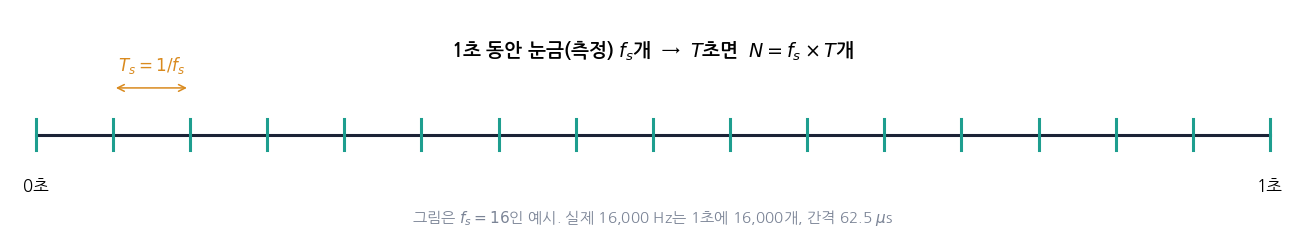

**나이퀴스트-섀넌 샘플링 정리 (Nyquist-Shannon)**: 신호에 들어 있는 가장 높은 주파수가 $f_{\max}$일 때, 원래 신호를 완벽히 되살리려면

$$
f_s > 2 f_{\max} \qquad \Longleftrightarrow \qquad f_{\max} < \frac{f_s}{2} = f_N \ (\text{나이퀴스트 주파수})
$$

**Aliasing 주파수**: $f_N$보다 높은 주파수 $f$는 다음 위치로 **접혀서(fold)** 나타납니다.

$$
f_{\text{alias}} = \left| f - k \cdot f_s \right|, \qquad k = \text{round}\!\left(\frac{f}{f_s}\right)
$$

예) $f_s = 11{,}025$ Hz에서 $f = 7{,}000$ Hz → $|7000 - 1 \times 11025| = 4{,}025$ Hz로 들림

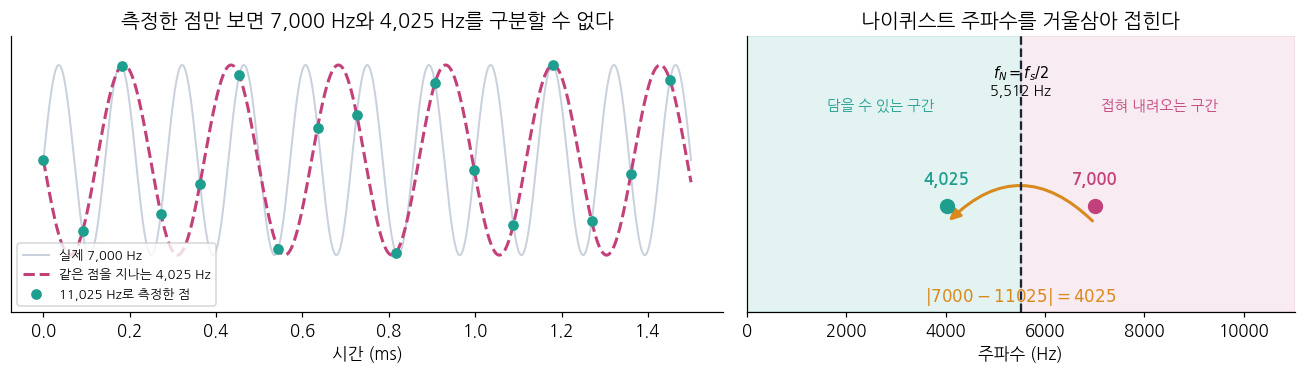

**왜 접힐까?** 왼쪽 그림에서 초록 점(측정값)은 회색 7,000 Hz 곡선 위에 있지만, 분홍 4,025 Hz 곡선 위에도 정확히 놓입니다. 측정값만 가진 컴퓨터는 둘 중 더 낮은 주파수로 해석합니다. 그래서 $f_N$을 넘는 주파수는 $f_N$을 기준으로 거울처럼 접힌 위치에 나타납니다.

**Resample 후 샘플 수**: $N_{\text{new}} = N \times \dfrac{f_{s,\text{new}}}{f_{s,\text{old}}}$. 이때 `librosa.resample()`은 줄이기 전에 $f_{s,\text{new}}/2$ 위의 성분을 **저역 통과 필터(low-pass filter)**로 먼저 제거합니다.

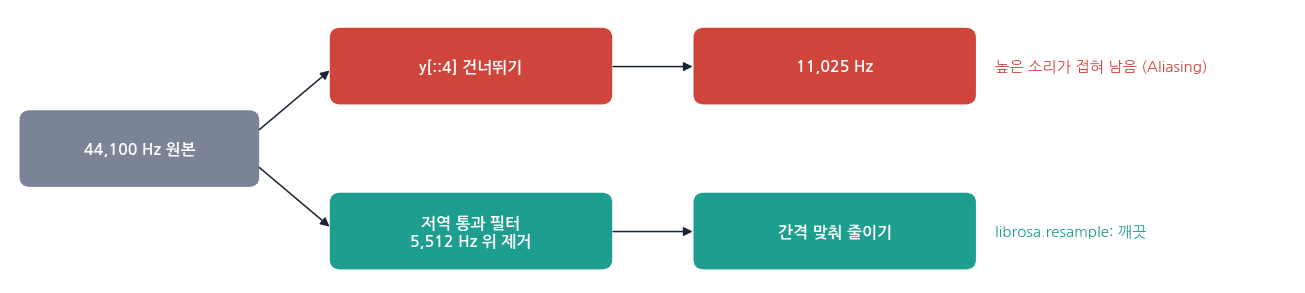

> 🎬 **애니메이션 D2-3:** [샘플링](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#sampling) — T_s, N, f_N, 1,800 Hz 성분의 f_alias가 샘플링 레이트에 따라 계산됩니다

In [ ]:
# ▶️ 수식 검증 2: Aliasing 주파수 예측 vs 실제 측정
def peak_freq(y, sr):
    spec = np.abs(np.fft.rfft(y * np.hanning(len(y))))
    return np.argmax(spec) * sr / len(y)

def alias_freq(f, fs):
    k = round(f / fs)
    return abs(f - k * fs)

fs_old, fs_new = 44100, 11025
print(f"새 나이퀴스트 주파수 f_N = {fs_new / 2:.0f} Hz\n")
print(f"{'원래 f':>8s} {'예측 f_alias':>12s} {'건너뛰기 측정':>12s} {'resample 후 남은 크기':>20s}")
for f in [1000, 3000, 5000, 7000, 9000]:
    y = tone(f, sec=1, sr=fs_old)
    skip_f = peak_freq(y[::4], fs_new)
    res = librosa.resample(y, orig_sr=fs_old, target_sr=fs_new)[200:-200]
    keep_db = 20 * np.log10(np.sqrt(np.mean(res**2)) / np.sqrt(np.mean(y**2)) + 1e-12)
    pred = f if f < fs_new / 2 else alias_freq(f, fs_new)
    print(f"{f:8d} {pred:12.0f} {skip_f:12.0f} {keep_db:17.1f} dB   {'(접힘)' if f > fs_new / 2 else ''}")
print("\n건너뛰기: f_N을 넘는 소리가 예측한 f_alias로 접혀 그대로 남음")
print("resample: f_N을 넘는 소리는 약 -140 dB (사실상 0)로 지워짐")

N = len(y44); print(f"\nN_new 예측 = {N} × 16000/{sr44} = {N * 16000 / sr44:.0f}, 실제 = {len(librosa.resample(y44, orig_sr=sr44, target_sr=16000))}")

#### 🔍 코드 해설: 수식 검증 2의 FFT

| 코드 | 하는 일 |
|---|---|
| `np.fft.rfft(y * np.hanning(len(y)))` | 실수 신호의 FFT. Hann 창을 곱해 끝부분이 갑자기 잘리는 효과(누설)를 줄임 |
| `np.argmax(spec) * sr / len(y)` | 가장 큰 성분의 번호 $k$를 주파수로: $f = k \cdot f_s / N$. 1초 신호면 해상도 $\Delta f = f_s/N = 1$ Hz |
| `k = round(f / fs); abs(f - k * fs)` | Aliasing 공식 $f_{alias} = |f - k f_s|$ 그대로 |
| `librosa.resample(...)[200:-200]` | 앞뒤 가장자리는 필터가 덜 안정적이라 잘라내고 세기를 잼 |

### 🧩 빈칸 실습 2: 음성 모델용으로 줄이기
44,100 Hz 원본(`y44`)을 음성 모델 표준 샘플링 레이트로 바꾸세요.

In [ ]:
# 🧩 빈칸 실습 2
y16 = librosa.resample(y44, orig_sr=sr44, target_sr=____)    # 음성 모델 표준

print(f"샘플 {len(y44):,}개 → {len(y16):,}개")
display(Audio(y16, rate=16000))
check(abs(len(y16) / len(y44) - 16000 / 44100) < 0.001, hint="Whisper가 쓰는 샘플링 레이트는? (D1 Part 2)")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
y16 = librosa.resample(y44, orig_sr=sr44, target_sr=16000)
```

**해설**: 16,000 Hz로 바꾸면 샘플 수가 약 36%(16,000 ÷ 44,100)로 줄어듭니다. 실제로는 `librosa.load("파일", sr=16000)`처럼 불러오면서 한 번에 바꾸는 경우가 많습니다.

</details>

---
### 📝 1교시 마무리: 개념 워크시트

> **[worksheet.html 열기 → 1교시 탭](https://imguru-mooc.github.io/AI_Voice/day02/worksheet.html)** — 주파수 · 진폭, dB, 샘플링 레이트, 나이퀴스트, Aliasing
>
> 10문항을 풀고 **채점하기**를 누르세요. 결과 코드와 해설이 나옵니다. 채점 후에는 답이 잠깁니다. 제출은 4교시까지 모두 마친 뒤 한 번에 합니다.

## Part 3. 양자화: 소리의 크기를 몇 단계로 적을까

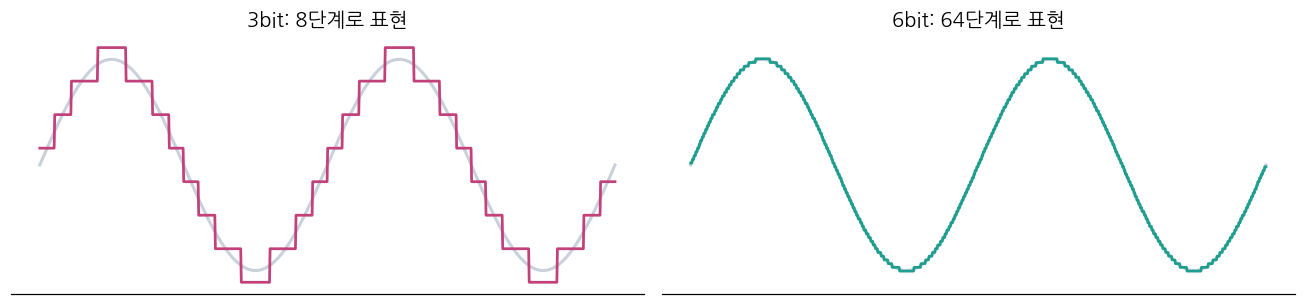

**비트 깊이**(bit depth)는 측정한 크기를 몇 단계로 적는지입니다. 단계가 적으면 계단처럼 거칠어지고 "지지직" 잡음이 생깁니다.

| 비트 깊이 | 단계 수 | 쓰는 곳 |
|---|---|---|
| 8bit | 256 | 옛날 게임, 전화 |
| **16bit** | **65,536** | **CD, 음성 데이터 (가장 흔함)** |
| 24bit | 약 1,677만 | 녹음 스튜디오 |
| 32bit float | 소수로 저장 | librosa가 불러온 배열 (`float32`) |

> 🎬 **애니메이션 D2-4:** [양자화 체험](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#quant) — 비트 수를 줄이며 계단 모양과 잡음 듣기

In [ ]:
def quantize(y, bits):
    # -1 ~ 1 사이의 소리를 bits 비트(2**bits 단계)로 거칠게 만든다
    half = 2 ** (bits - 1) - 1
    return np.round(y * half) / half

y = librosa.load("speech.wav", sr=SR)[0]
for bits in [16, 8, 4, 2]:
    print(f"{bits}bit ({2 ** bits:,}단계)")
    display(Audio(quantize(y, bits), rate=SR))

#### 🔍 코드 해설: quantize() 함수

| 코드 | 하는 일 |
|---|---|
| `half = 2 ** (bits - 1) - 1` | 양수 쪽 최대 단계. 16bit면 $2^{15}-1 = 32767$ (실제 16bit 정수 최대값과 같음) |
| `np.round(y * half)` | $[-1, 1]$을 $[-32767, 32767]$로 늘린 뒤 **가장 가까운 정수**로 반올림 → 여기서 양자화 오차 발생 |
| `/ half` | 다시 $[-1, 1]$로 줄여 재생할 수 있게 함. 값은 이제 $\Delta = 1/\text{half}$ 간격의 계단 |

오차는 반올림에서만 생기므로 크기는 최대 $\Delta/2$입니다. 비트가 줄면 $\Delta$가 커져 잡음이 들립니다.

In [ ]:
# 파일로 저장할 때 비트 깊이 정하기: subtype
for subtype in ["PCM_16", "PCM_24", "FLOAT"]:
    sf.write(f"q_{subtype}.wav", y, SR, subtype=subtype)
    info = sf.info(f"q_{subtype}.wav")
    print(f"{subtype:7s} → {info.subtype_info:22s} {size_kb(f'q_{subtype}.wav'):7.1f} KB")

#### 🔍 코드 해설: subtype

| 코드 | 하는 일 |
|---|---|
| `sf.write(path, y, SR, subtype="PCM_16")` | float 배열을 16bit 정수로 바꿔 저장 (내부에서 $\times 32767$ 후 반올림) |
| `"PCM_24" / "FLOAT"` | 24bit 정수 / 32bit 소수. 샘플당 3바이트 / 4바이트 |
| `info.subtype_info` | 저장된 형식을 사람이 읽기 쉬운 이름으로 |

파일 크기 비율 16 : 24 : 32bit = 2 : 3 : 4 바이트가 출력에서 그대로 보입니다 ($187.5 : 281.3 : 375.1$ KB).

### 3-1. 📐 수식으로 보기: 양자화 단계와 양자화 잡음

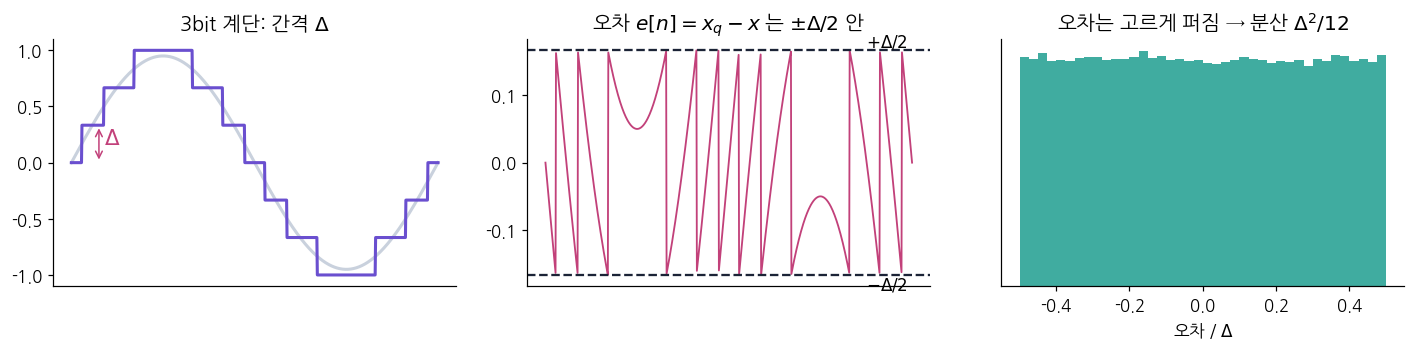

**단계 수와 단계 간격**: $b$비트는 $2^b$단계를 표현합니다. $[-1, 1]$ 범위를 나누면 한 단계의 간격(step size)은

$$
L = 2^b, \qquad \Delta \approx \frac{2}{2^b} = 2^{1-b}
$$

**양자화 오차**: 반올림으로 생기는 오차 $e[n] = x_q[n] - x[n]$는 $[-\Delta/2, +\Delta/2]$ 범위에 고르게 퍼져 있다고 볼 수 있고, 그 세기(분산)는

$$
\sigma_e^2 = \frac{\Delta^2}{12}
$$

**신호 대 잡음비 (SNR)**: 꽉 찬(full-scale) 사인파를 $b$비트로 양자화하면

$$
\text{SNR} = 10\log_{10}\frac{P_{\text{signal}}}{P_{\text{noise}}} \approx 6.02\,b + 1.76 \ \text{dB}
$$

→ **1비트 늘 때마다 약 6 dB 깨끗해집니다.** 16bit면 약 98 dB, 8bit면 약 50 dB입니다.

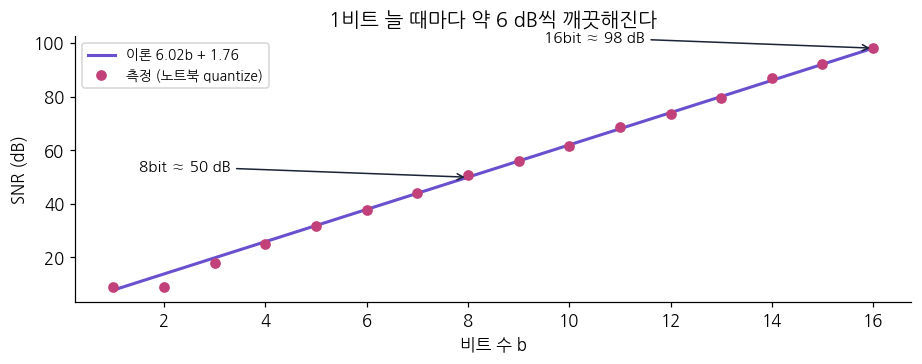

**6.02는 어디서 왔을까?** 1비트가 늘면 단계 간격 $\Delta$가 절반이 되고, 잡음 세기 $\Delta^2/12$는 4분의 1이 됩니다. $10\log_{10}4 \approx 6.02$ dB. 즉 "간격 절반 → 잡음 4분의 1 → 6 dB"입니다.

**샘플 하나의 바이트 수**: $b/8$ 바이트 (16bit → 2바이트, 24bit → 3바이트)

> 🎬 **애니메이션 D2-4:** [양자화](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#quant) — 비트 수를 바꾸면 L = 2^b, Δ, SNR이 함께 바뀝니다

In [ ]:
# ▶️ 수식 검증 3: 비트별 SNR 측정 vs 6.02b + 1.76
x = tone(440, sec=1, amp=0.999)          # 꽉 찬 사인파
print(f"{'bits':>4s} {'단계 2^b':>10s} {'Δ':>10s} {'측정 SNR':>10s} {'이론 SNR':>10s}")
for b in [2, 4, 8, 12, 16]:
    xq = quantize(x, b)
    noise = xq - x
    snr = 10 * np.log10(np.mean(x**2) / np.mean(noise**2))
    print(f"{b:4d} {2**b:10,d} {2 / 2**b:10.6f} {snr:9.1f}dB {6.02 * b + 1.76:9.1f}dB")

#### 🔍 코드 해설: 수식 검증 3의 SNR 계산

| 코드 | 하는 일 |
|---|---|
| `x = tone(440, sec=1, amp=0.999)` | SNR 공식은 **꽉 찬 사인파** 기준이라 진폭을 1에 가깝게 |
| `noise = xq - x` | 양자화 오차 $e[n]$ |
| `10 * np.log10(np.mean(x**2) / np.mean(noise**2))` | $\text{SNR} = 10\log_{10}(P_s/P_e)$. 세기(제곱 평균)의 비율이라 20이 아니라 **10** |

2bit에서 측정값이 이론보다 낮은 것은, 단계가 너무 적어 "오차가 고르게 퍼진다"는 가정이 맞지 않기 때문입니다. 비트가 충분하면 이론과 거의 같아집니다.

### 🧩 빈칸 실습 3: 16bit WAV로 저장하기
음성 데이터에서 가장 흔한 형식인 16bit로 저장하세요. 위 셀의 `subtype` 이름을 참고합니다.

In [ ]:
# 🧩 빈칸 실습 3
sf.write("my_16bit.wav", y, SR, subtype="____")

info = sf.info("my_16bit.wav")
print(info.subtype, "|", info.subtype_info)
check(info.subtype == "PCM_16", hint="PCM_ 뒤에 비트 수를 붙입니다.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
sf.write("my_16bit.wav", y, SR, subtype="PCM_16")
```

**해설**: `PCM_16`은 16bit 정수로 저장하라는 뜻입니다. 24bit는 `PCM_24`, 소수 그대로는 `FLOAT`입니다. 같은 소리라도 비트 깊이가 클수록 파일이 커집니다 (16bit → 24bit는 1.5배).

</details>

## Part 4. 채널: mono와 stereo

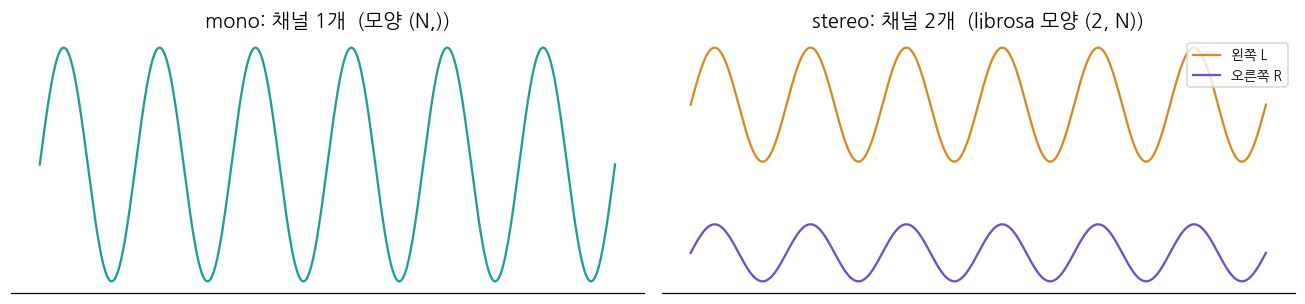

- **mono**: 소리 줄기가 1개. 음성 모델은 mono를 씁니다.
- **stereo**: 왼쪽, 오른쪽 2개. 음악이나 영상에서 씁니다.

> ⚠️ **라이브러리마다 모양이 다릅니다.** librosa는 `(채널, 샘플)`, soundfile은 `(샘플, 채널)` 순서입니다. 저장할 때 `.T`(뒤집기)가 필요한 이유입니다.

> 🎬 **애니메이션 D2-5:** [채널 체험](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#channel) — 소리를 왼쪽, 오른쪽으로 옮겨 듣기

In [ ]:
left  = tone(440, sec=2)          # 왼쪽: 라
right = tone(660, sec=2)          # 오른쪽: 미
stereo = np.stack([left, right])  # librosa 방식 모양 (2, N)
print("stereo 모양:", stereo.shape)
display(Audio(stereo, rate=SR))   # 이어폰으로 들으면 왼쪽, 오른쪽이 다르게 들립니다

sf.write("stereo.wav", stereo.T, SR)   # soundfile은 (N, 2) 모양이 필요 → .T
print("soundfile로 읽은 모양:", sf.read("stereo.wav")[0].shape)
print("librosa로 읽은 모양  :", librosa.load("stereo.wav", sr=None, mono=False)[0].shape)

#### 🔍 코드 해설: stereo 만들기와 모양

| 코드 | 하는 일 |
|---|---|
| `np.stack([left, right])` | 두 1차원 배열 $(N,)$을 위아래로 쌓아 $(2, N)$. librosa 방식 |
| `Audio(stereo, rate=SR)` | IPython Audio는 $(채널, 샘플)$ 모양을 받음 → 왼쪽, 오른쪽이 따로 재생 |
| `sf.write(path, stereo.T, SR)` | `.T` 전치로 $(N, 2)$. soundfile은 $(샘플, 채널)$ 순서 |
| `librosa.load(..., mono=False)` | stereo를 합치지 않고 $(2, N)$으로 불러옴 |

> ⚠️ `.T` 없이 `(2, N)`을 저장하면 soundfile은 "샘플 2개, 채널 N개"로 해석해 오류가 나거나 이상한 파일이 됩니다.

### 🧩 빈칸 실습 4: stereo를 mono로 합치기
두 채널의 평균을 내면 mono가 됩니다. `stereo`의 모양은 `(2, N)`입니다. 어느 축(axis)으로 평균을 내야 할까요?

In [ ]:
# 🧩 빈칸 실습 4
mono = stereo.mean(axis=____)

print("mono 모양:", mono.shape)
display(Audio(mono, rate=SR))
check(mono.shape == (stereo.shape[1],), hint="채널이 있는 첫 번째 축은 0번입니다.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
mono = stereo.mean(axis=0)
```

**해설**: 모양 `(2, N)`에서 0번 축이 채널, 1번 축이 시간입니다. `axis=0`으로 평균을 내면 채널이 합쳐져 `(N,)`이 됩니다. `librosa.to_mono(stereo)`도 같은 일을 합니다. `librosa.load()`는 기본값 `mono=True`라서 불러오면서 자동으로 합쳐 줍니다.

</details>

### 4-1. 📐 수식으로 보기: 채널 합치기

stereo를 mono로 합칠 때는 두 채널의 **평균**을 냅니다.

$$
x_{\text{mono}}[n] = \frac{x_L[n] + x_R[n]}{2}
$$

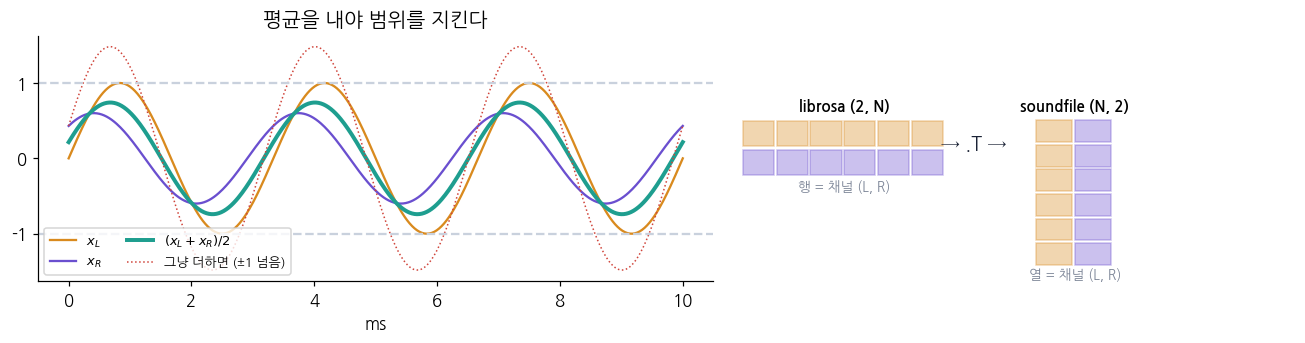

- 평균을 내는 이유: 그냥 더하면 $x_L + x_R$가 $[-1, 1]$을 넘어 **소리가 찢어질(clipping)** 수 있습니다.
- 배열 관점: librosa 모양 $(C, N)$에서 축 0의 평균 → $(N,)$. soundfile 모양 $(N, C)$는 행렬 전치 $X^\top$로 서로 바뀝니다.

> 🎬 **애니메이션 D2-5:** [채널](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#channel) — 좌우 이동과 (2, N) / (N, 2) 모양 비교

In [ ]:
# ▶️ 수식 검증 4: (L + R) / 2 와 mean(axis=0)은 같은가?
mono_formula = (stereo[0] + stereo[1]) / 2
print("두 방법이 같은가:", np.allclose(mono_formula, stereo.mean(axis=0)))
print(f"그냥 더했을 때 최대값 {np.abs(stereo[0] + stereo[1]).max():.2f} (1을 넘으면 clipping 위험) | 평균 최대값 {np.abs(mono_formula).max():.2f}")
print("전치 확인:", stereo.shape, "→", stereo.T.shape)

---
### 📝 2교시 마무리: 개념 워크시트

> **[worksheet.html 열기 → 2교시 탭](https://imguru-mooc.github.io/AI_Voice/day02/worksheet.html)** — 양자화 단계, SNR, subtype, 채널과 배열 모양
>
> 10문항을 풀고 **채점하기**를 누르세요. 결과 코드와 해설이 나옵니다. 채점 후에는 답이 잠깁니다. 제출은 4교시까지 모두 마친 뒤 한 번에 합니다.

## Part 5. 오디오 파일 포맷: WAV, FLAC, MP3, Opus

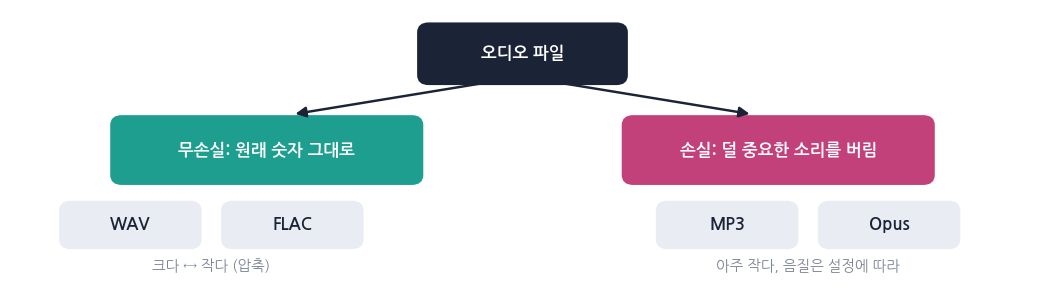

| 포맷 | 종류 | 특징 | 음성 AI에서 |
|---|---|---|---|
| **WAV** | 무손실, 압축 없음 | 크지만 가장 단순하고 빠름 | 학습, 추론 입력의 표준 |
| **FLAC** | 무손실 압축 | 원래 숫자 그대로, 크기는 줄어듦 | 데이터셋 보관 |
| **MP3** | 손실 압축 | 작고 어디서나 재생 | 배포, 다운로드 |
| **Opus** | 손실 압축 | 낮은 비트레이트에서도 음성이 깨끗함 | 실시간 통화, WebRTC (6주차) |

**WAV 크기 계산**: 1초당 샘플 수 × 샘플 하나의 바이트 수 × 채널 수 × 길이(초)
예) 16,000 × 2바이트(16bit) × 1채널 × 10초 = 320,000바이트 ≈ 313 KB

> 🎬 **애니메이션 D2-6:** [포맷 비교 계산기](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#format) — 설정에 따라 파일 크기가 어떻게 바뀌는지 보기

In [ ]:
y, sr = librosa.load("speech.wav", sr=SR)
sf.write("f.wav",  y, sr, subtype="PCM_16")
sf.write("f.flac", y, sr, subtype="PCM_16")
ffmpeg("-i", "f.wav", "-b:a", "64k", "f.mp3")
ffmpeg("-i", "f.wav", "-c:a", "libopus", "-b:a", "24k", "f.opus")

def decode(path):
    # 어떤 포맷이든 16kHz mono 배열로 되돌리기
    ffmpeg("-i", path, "-ar", str(SR), "-ac", "1", "tmp_decode.wav")
    return sf.read("tmp_decode.wav", dtype="float32")[0]

ref = decode("f.wav")
print(f"{'파일':8s} {'크기(KB)':>9s} {'WAV 대비':>8s}   원래 숫자와의 차이")
for f in ["f.wav", "f.flac", "f.mp3", "f.opus"]:
    d = decode(f); n = min(len(d), len(ref))
    diff = np.abs(d[:n] - ref[:n]).max()
    print(f"{f:8s} {size_kb(f):9.1f} {size_kb(f) / size_kb('f.wav'):8.0%}   {'0 (완전히 같음)' if diff == 0 else f'{diff:.4f}'}")

#### 🔍 코드 해설: 포맷 비교

| 코드 | 하는 일 |
|---|---|
| `sf.write("f.flac", y, sr, subtype="PCM_16")` | 확장자로 형식이 정해짐. FLAC은 무손실 압축 |
| `ffmpeg("-i", "f.wav", "-b:a", "64k", "f.mp3")` | `-b:a` audio bitrate. 64 kbps MP3로 손실 압축 |
| `"-c:a", "libopus", "-b:a", "24k"` | `-c:a` codec 지정. Opus 24 kbps |
| `decode(path)` | 어떤 포맷이든 ffmpeg로 같은 16kHz mono WAV로 풀어서 숫자 배열로 → 공정하게 비교 |
| `np.abs(d[:n] - ref[:n]).max()` | 원래 숫자와 가장 많이 다른 곳의 차이. 0이면 완전히 같음(무손실) |

> 💡 Opus의 차이가 크게 나오는 이유 중 하나는 코덱이 앞부분에 아주 짧은 지연(pre-skip)을 두기 때문입니다. 소리가 조금 밀려도 차이로 계산됩니다.

In [ ]:
for f in ["f.wav", "f.flac", "f.mp3", "f.opus"]:
    print(f); display(Audio(f))

> ❓ **생각해 보기:** FLAC은 WAV보다 작은데도 숫자가 **완전히 같습니다** (무손실). MP3와 Opus는 훨씬 작지만 숫자가 조금씩 바뀝니다 (손실). 귀로 듣기에는 차이가 거의 없죠? 그래서 사람에게는 MP3, Opus가 좋고, 모델 학습 데이터에는 WAV나 FLAC을 씁니다.

### 5-1. 📐 수식으로 보기: 비트레이트와 압축률

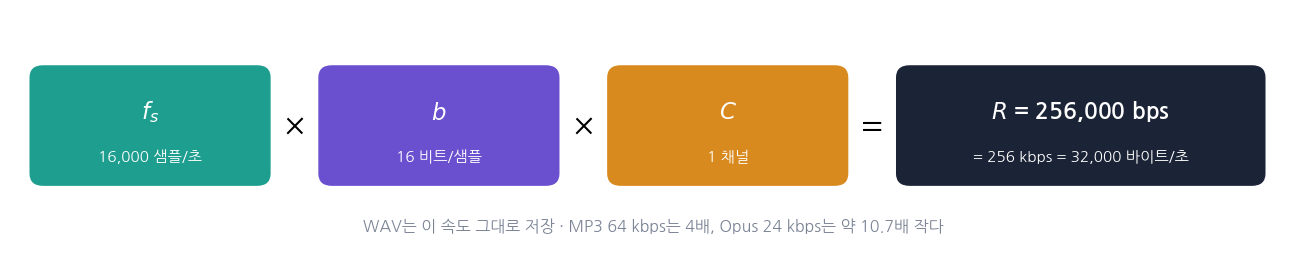

**PCM(WAV) 비트레이트**: 1초에 필요한 비트 수

$$
R_{\text{PCM}} = f_s \times b \times C \ \ [\text{bps}]
$$

예) $16{,}000 \times 16 \times 1 = 256{,}000$ bps $= 256$ kbps

**WAV 파일 크기** (헤더 44바이트 포함)

$$
\text{bytes} = f_s \times \frac{b}{8} \times C \times T + 44
$$

**손실 압축의 크기**: MP3, Opus는 비트레이트 $R$을 정해서 저장하므로

$$
\text{bytes} \approx \frac{R \times T}{8}, \qquad \text{압축률} = \frac{R_{\text{PCM}}}{R}
$$

예) 256 kbps WAV → 64 kbps MP3: 압축률 $256/64 = 4$배, 24 kbps Opus: 약 $10.7$배

FLAC은 비트레이트를 정하지 않고 **원래 숫자를 그대로 되살릴 수 있는 만큼만** 압축하므로, 압축률이 소리마다 달라집니다.

> 🎬 **애니메이션 D2-6:** [포맷 계산기](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#format) — R = f_s·b·C와 압축률이 설정에 따라 계산됩니다

In [ ]:
# ▶️ 수식 검증 5: 비트레이트 공식으로 크기 예측 vs 실제
T = len(y) / SR
R_pcm = SR * 16 * 1
print(f"R_PCM = {SR} × 16 × 1 = {R_pcm / 1000:.0f} kbps, 길이 {T:.2f}초\n")
for f, R in [("f.mp3", 64_000), ("f.opus", 24_000)]:
    pred = R * T / 8 / 1024
    print(f"{f:7s} 예측 {pred:6.1f} KB | 실제 {size_kb(f):6.1f} KB | 압축률 {R_pcm / R:.1f}배")
print(f"f.flac  실제 압축률 {size_kb('f.wav') / size_kb('f.flac'):.1f}배 (소리에 따라 다름)")

### 🧩 빈칸 실습 5: WAV 파일 크기 예측하기
16bit 샘플 하나는 몇 바이트일까요? (1바이트 = 8bit) 예측한 크기와 실제 파일 크기를 비교합니다.

In [ ]:
# 🧩 빈칸 실습 5
bytes_per_sample = ____                     # 16bit = ? 바이트
seconds = len(y) / SR
predict = SR * bytes_per_sample * 1 * seconds   # 1초당 샘플 수 × 바이트 × 채널 × 초

actual = os.path.getsize("f.wav")
print(f"예측 {predict:,.0f} 바이트 | 실제 {actual:,} 바이트 (차이 {actual - predict:,.0f}: 파일 머리말)")
check(abs(actual - predict) < 100, hint="16 ÷ 8 = ?")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
bytes_per_sample = 2
```

**해설**: 16bit ÷ 8 = 2바이트입니다. 실제 파일은 예측보다 44바이트쯤 큰데, 이것은 샘플링 레이트나 채널 수를 적어 둔 **헤더(머리말)**입니다. 24bit면 3바이트, stereo면 2배가 됩니다.

</details>

---
### 📝 3교시 마무리: 개념 워크시트

> **[worksheet.html 열기 → 3교시 탭](https://imguru-mooc.github.io/AI_Voice/day02/worksheet.html)** — 무손실 · 손실 포맷, 비트레이트, WAV 크기, 압축률
>
> 10문항을 풀고 **채점하기**를 누르세요. 결과 코드와 해설이 나옵니다. 채점 후에는 답이 잠깁니다. 제출은 4교시까지 모두 마친 뒤 한 번에 합니다.

## Part 6. 오디오 다루는 도구들과 전처리기

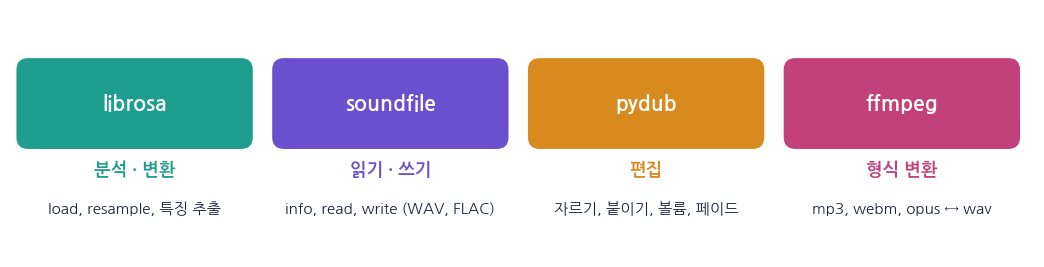

| 하고 싶은 일 | 도구 |
|---|---|
| 파일 정보만 빨리 보기, 읽고 쓰기 | `soundfile` |
| 분석, 샘플링 레이트 바꾸기, 특징 추출 | `librosa` |
| 자르기, 이어 붙이기, 볼륨, 페이드 같은 편집 | `pydub` |
| mp3, webm, opus 등 형식 바꾸기 | `ffmpeg` |

> 🎬 **애니메이션 D2-7:** [도구 고르기](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#libs) — 상황 8개에 알맞은 도구를 골라 보는 퀴즈

### 6-1. pydub으로 편집하기
pydub은 시간을 **밀리초(ms)** 단위로 다룹니다. 1초 = 1,000ms입니다.

> 🎬 **애니메이션 D2-8:** [pydub 편집기](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#editor) — 자르기, 볼륨, 페이드를 조작하면 코드가 바뀌는 시뮬레이터

In [ ]:
from pydub import AudioSegment

audio = AudioSegment.from_file("speech.wav")
print(f"길이 {len(audio)} ms | {audio.frame_rate} Hz | {audio.channels}ch | {audio.sample_width * 8}bit")

def play(seg, name="tmp_play.wav"):
    seg.export(name, format="wav"); display(Audio(name))

clip  = audio[1000:4000]                      # 1초 ~ 4초 자르기
loud  = clip + 6                              # 6dB 키우기 (약 2배)
faded = clip.fade_in(500).fade_out(1000)      # 0.5초 페이드 인, 1초 페이드 아웃
both  = clip + AudioSegment.silent(800) + clip.reverse()   # 이어 붙이기 (중간 0.8초 쉼)

for name, seg in [("자르기", clip), ("+6dB", loud), ("페이드", faded), ("이어 붙이기", both)]:
    print(name); play(seg)

#### 🔍 코드 해설: pydub 편집

| 코드 | 하는 일 |
|---|---|
| `AudioSegment.from_file("speech.wav")` | 파일을 pydub 객체로 불러옴. 내부에는 16bit 정수로 저장 |
| `len(audio)` | 길이를 **밀리초**로 돌려줌 (numpy 배열의 len은 샘플 수라 다름) |
| `audio[1000:4000]` | 1,000ms ~ 4,000ms 구간. 리스트 슬라이싱과 같은 문법 |
| `clip + 6` | 숫자를 더하면 **볼륨(dB)**: $g = 10^{6/20} \approx 1.995$배 |
| `clip + AudioSegment.silent(800) + clip` | 객체끼리 더하면 **이어 붙이기**. silent(800)은 0.8초 무음 |
| `seg.export(name, format="wav")` | 파일로 저장. mp3 등은 내부에서 ffmpeg 사용 |

> ⚠️ 같은 `+`라도 숫자를 더하면 볼륨, 소리를 더하면 이어 붙이기입니다.

### 6-1-1. 📐 수식으로 보기: dB 이득과 페이드

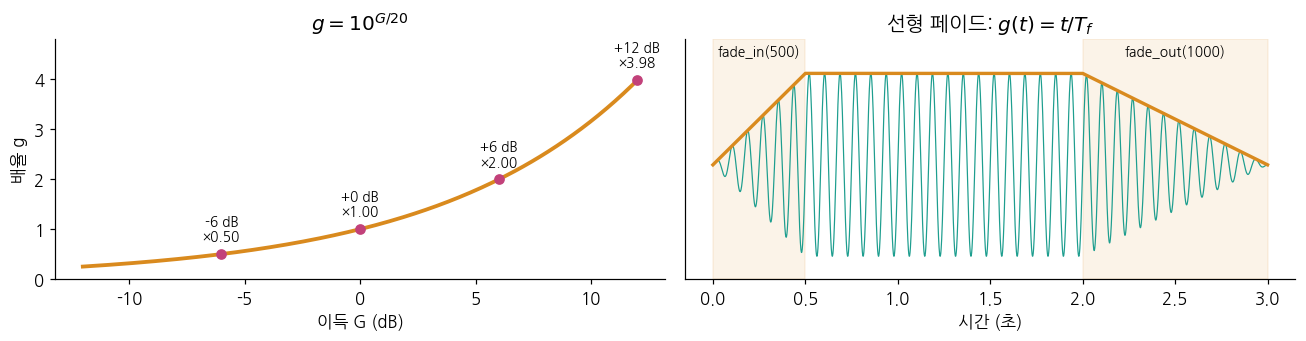

**dB 이득 → 배율**: pydub의 `clip + 6`은 진폭에 다음 배율을 곱합니다.

$$
g = 10^{\,G_{\text{dB}}/20}, \qquad +6\,\text{dB} \Rightarrow g = 10^{0.3} \approx 1.995 \ (\text{약 } 2\text{배})
$$

**선형 페이드 인**: 길이 $T_f$ 동안 배율을 0에서 1로 올립니다. $\;g(t) = \min\!\left(\dfrac{t}{T_f}, 1\right)$

**밀리초와 샘플**: $t$ ms 지점의 샘플 번호 $n = f_s \times t / 1000$ (16kHz에서 1ms = 16샘플)

> 🎬 **애니메이션 D2-8:** [pydub 편집기](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#editor) — 볼륨을 바꾸면 g = 10^(G/20) 배율이 코드 주석에 표시됩니다

In [ ]:
# ▶️ 수식 검증 6: +6 dB는 정말 약 2배인가?
a = np.array(clip.get_array_of_samples(), dtype=np.float32)
b = np.array(loud.get_array_of_samples(), dtype=np.float32)
print(f"측정 배율 = {np.abs(b).max() / np.abs(a).max():.3f} | 이론 10^(6/20) = {10 ** (6 / 20):.3f}")
for g in [-12, -6, 3, 12]:
    print(f"{g:+3d} dB → ×{10 ** (g / 20):.3f}")
print(f"\n1초 지점 샘플 번호 = 16000 × 1000 / 1000 = {int(SR * 1000 / 1000)}")

### 🧩 빈칸 실습 6: 앞부분 2초만 잘라 mp3로 저장하기

In [ ]:
# 🧩 빈칸 실습 6
first2 = audio[:____]                         # 처음 2초 (단위: ms)
first2.export("first2.mp3", format="mp3")

print(f"길이 {len(first2)} ms | 파일 {size_kb('first2.mp3'):.1f} KB")
display(Audio("first2.mp3"))
check(len(first2) == 2000, hint="pydub은 밀리초 단위입니다. 2초 = ? ms")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
first2 = audio[:2000]
```

**해설**: pydub은 리스트처럼 `[시작:끝]`으로 자르며 단위는 밀리초입니다. `audio[:2000]`은 처음부터 2,000ms(2초)까지입니다. `export()`의 `format`만 바꾸면 wav, mp3, ogg 등으로 저장할 수 있습니다 (내부에서 ffmpeg 사용).

</details>

### 6-2. 미니 프로젝트: 어떤 파일이든 음성 모델용으로 바꾸는 전처리기

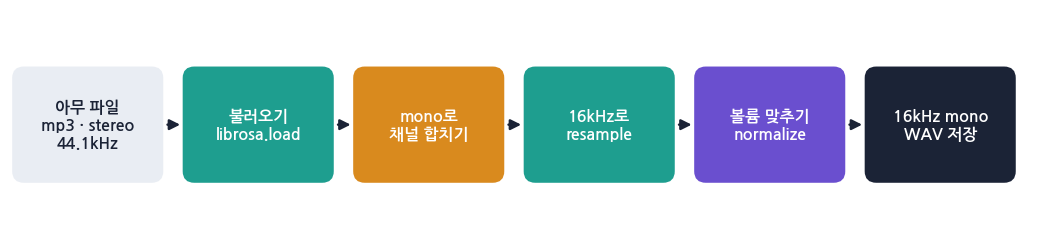

오늘 배운 것을 모두 합쳐, **어떤 형식, 샘플링 레이트, 채널의 파일이 와도** 음성 모델이 바로 쓸 수 있는 **16kHz mono 16bit WAV**로 바꾸는 함수를 만듭니다. D3부터 이 함수를 계속 씁니다.

> 🎬 **애니메이션 D2-9:** [전처리 파이프라인](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#pipeline) — 파일 정보가 단계마다 어떻게 바뀌는지 보기

### 6-2-1. 📐 수식으로 보기: 전처리기의 세 가지 계산

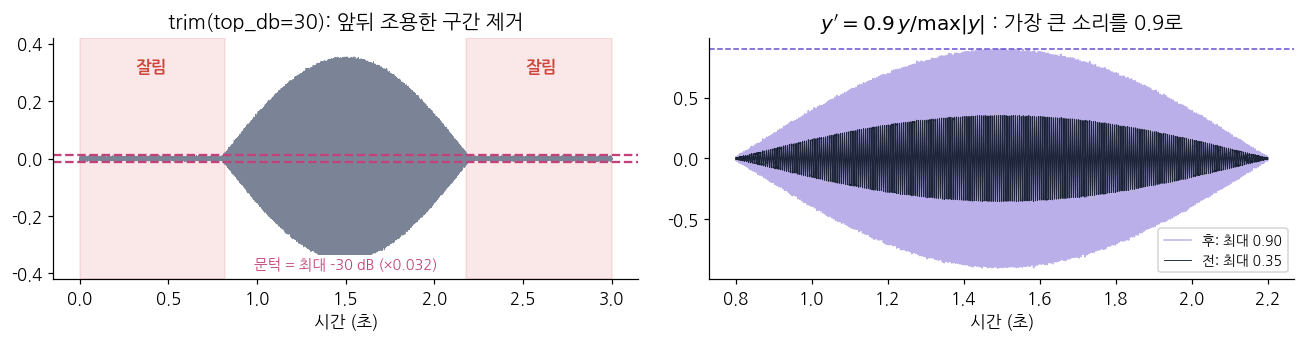

| 단계 | 수식 | 뜻 |
|---|---|---|
| Resample | $N_{\text{new}} = N \cdot \dfrac{16000}{f_s}$ | 16kHz 기준으로 샘플 수 조정 |
| Trim (`top_db=30`) | 프레임 세기가 $\max - 30$ dB 미만이면 묵음 → 진폭 비율 $10^{-30/20} \approx 0.032$ | 가장 큰 소리의 약 3% 미만 구간을 앞뒤에서 제거 |
| Peak normalize | $y' = y \cdot \dfrac{0.9}{\max\lvert y \rvert + \varepsilon}$ | 가장 큰 소리를 0.9로. $\varepsilon$은 0으로 나누기 방지 |

> 🎬 **애니메이션 D2-9:** [전처리 파이프라인](https://imguru-mooc.github.io/AI_Voice/day02/animation.html#pipeline) — 단계마다 파일 정보 카드가 바뀌고 해당 코드 줄이 강조됩니다

### 🧩 빈칸 실습 7: 전처리기 완성하기
`librosa.load()`에 **샘플링 레이트**와 **mono 여부**를 채우세요.

In [ ]:
# 🧩 빈칸 실습 7
def make_model_ready(src, dst="ready.wav"):
    y, sr = librosa.load(src, sr=____, mono=____)       # ① 16kHz로, ② 채널 합치기
    y, _ = librosa.effects.trim(y, top_db=30)            # 앞뒤 묵음 자르기
    y = y / (np.abs(y).max() + 1e-9) * 0.9               # 볼륨 맞추기 (가장 큰 소리를 0.9로)
    sf.write(dst, y, sr, subtype="PCM_16")               # 16bit WAV 저장
    return dst

def describe(path):
    i = sf.info(path)
    return f"{i.samplerate:>6} Hz | {i.channels}ch | {i.subtype:7s} | {i.duration:5.2f}초 | {size_kb(path):7.1f} KB"

for src in ["speech_hq.wav", "speech.mp3", "stereo.wav", "f.flac"]:
    out = make_model_ready(src, "ready_" + os.path.splitext(src)[0] + ".wav")
    print(f"[전] {src:22s} {describe(src)}")
    print(f"[후] {out:22s} {describe(out)}\n")

r = sf.info("ready_speech_hq.wav")
check(r.samplerate == 16000 and r.channels == 1 and r.subtype == "PCM_16", hint="① 16000 ② True")
display(Audio("ready_speech_hq.wav"))

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
def make_model_ready(src, dst="ready.wav"):
    y, sr = librosa.load(src, sr=16000, mono=True)
    ...
```

**해설**
- `sr=16000`: 불러오면서 16kHz로 바꿉니다 (내부에서 resample).
- `mono=True`: 채널을 합칩니다. 기본값이 True라서 생략해도 되지만, 의도를 분명히 적는 습관이 좋습니다.
- 44.1kHz stereo 파일도, mp3도, FLAC도 모두 같은 `16000 Hz | 1ch | PCM_16`이 됩니다. 이것이 **전처리**입니다.

</details>

#### 🔍 코드 해설: make_model_ready()

| 코드 | 하는 일 |
|---|---|
| `librosa.load(src, sr=16000, mono=True)` | ① 형식 해석 ② resample ③ 채널 평균 ④ float32 변환을 한 줄에. 결과 $y \in [-1, 1]$ |
| `librosa.effects.trim(y, top_db=30)` | 앞뒤에서 최대보다 30 dB 이상 작은 구간(진폭 약 3% 미만)을 잘라냄. (잘린 배열, 남은 구간 위치)를 돌려줌 |
| `y / (np.abs(y).max() + 1e-9) * 0.9` | peak normalize. $10^{-9}$은 무음일 때 0으로 나누기 방지, 0.9는 여유분(headroom) |
| `sf.write(dst, y, sr, subtype="PCM_16")` | 16bit 정수 WAV로 저장. 배열 모양이 $(N,)$이라 `.T`가 필요 없음 |
| `describe(path)` | sf.info로 헤더만 읽어 한 줄 요약 |

입력이 무엇이든 출력은 **16000 Hz · 1ch · PCM_16 · 최대 0.9**로 같아집니다. D3부터 모든 실습의 첫 단계입니다.

### 6-3. 내 목소리로 해보기 (선택)
D1에서 쓴 브라우저 녹음 함수로 녹음한 뒤 전처리기에 넣어 봅니다. 브라우저 녹음 파일은 **webm** 형식이라 librosa가 바로 못 읽으므로, ffmpeg로 먼저 wav로 바꿉니다.

In [ ]:
from base64 import b64decode
from IPython.display import Javascript

RECORD_JS = """
const sleep = t => new Promise(r => setTimeout(r, t));
const blobToDataURL = blob => new Promise(resolve => {
  const reader = new FileReader();
  reader.onloadend = () => resolve(reader.result);
  reader.readAsDataURL(blob);
});
var record = async (sec) => {
  const stream = await navigator.mediaDevices.getUserMedia({audio: true});
  const recorder = new MediaRecorder(stream);
  const chunks = [];
  recorder.ondataavailable = e => chunks.push(e.data);
  const stopped = new Promise(r => recorder.onstop = r);
  recorder.start();
  await sleep(sec * 1000);
  recorder.stop();
  await stopped;
  stream.getTracks().forEach(t => t.stop());
  return await blobToDataURL(new Blob(chunks));
};
"""

try:
    from google.colab.output import eval_js
    display(Javascript(RECORD_JS))
    print("🎙️ 5초간 녹음합니다. 지금 말씀하세요...")
    data_url = eval_js("record(5)")
    with open("my_voice.webm", "wb") as f:
        f.write(b64decode(data_url.split(",")[1]))
    ffmpeg("-i", "my_voice.webm", "my_voice_raw.wav")        # webm → wav (원래 설정 그대로)
    print("녹음 원본 :", describe("my_voice_raw.wav"))
    print("전처리 후 :", describe(make_model_ready("my_voice_raw.wav", "my_voice_ready.wav")))
    display(Audio("my_voice_ready.wav"))
except Exception as e:
    print("⚠️ 녹음을 건너뜁니다:", type(e).__name__, e)

---
### 📝 4교시 마무리: 개념 워크시트

> **[worksheet.html 열기 → 4교시 탭](https://imguru-mooc.github.io/AI_Voice/day02/worksheet.html)** — pydub 편집, dB 이득, 도구 고르기, 전처리기, trim · normalize
>
> 10문항을 풀고 **채점하기**를 누르세요. 결과 코드와 해설이 나옵니다. 채점 후에는 답이 잠깁니다. 제출은 4교시까지 모두 마친 뒤 한 번에 합니다. 4교시까지 마쳤다면 아래 Part 7의 **제출 방법**을 따라 노션에 제출하세요.

## Part 7. 정리 & 과제

### 오늘 배운 것
| 개념 | 핵심 | 수식 |
|---|---|---|
| 주파수 / 진폭 | 높낮이 / 크기 | $x[n] = A\sin(2\pi f n / f_s)$ |
| 데시벨 | 크기의 비율을 로그로 | $L = 20\log_{10}(A_1/A_0)$, $\times 2 \approx +6$ dB |
| 샘플링 | 1초에 몇 번 측정하나. 음성은 16,000 Hz | $N = f_s T$, $f_{\max} < f_s/2$ |
| Aliasing | 함부로 줄이면 높은 소리가 접혀 내려온다 | $f_{\text{alias}} = \lvert f - k f_s\rvert$ |
| 양자화 | 음성 데이터는 16bit (`PCM_16`) | $L = 2^b$, $\text{SNR} \approx 6.02b + 1.76$ dB |
| 채널 | mono 1개, stereo 2개 | $x_{\text{mono}} = (x_L + x_R)/2$ |
| 파일 크기 | 무손실 WAV, FLAC / 손실 MP3, Opus | $R = f_s b C$, bytes $= f_s \frac{b}{8} C T + 44$ |
| 편집 | pydub은 ms 단위 | $g = 10^{G/20}$ |
| 전처리기 | 어떤 파일이든 → 16kHz mono 16bit WAV | $y' = 0.9\,y / \max\lvert y\rvert$ |

### 📝 과제
1. 휴대폰으로 녹음한 파일(m4a 등)을 Colab에 올려 `make_model_ready()`로 변환하고, 변환 전후 `describe()` 결과를 비교해 제출하세요. (m4a는 `ffmpeg("-i", "파일.m4a", "in.wav")`로 먼저 wav로 바꿉니다.)
2. MP3 비트레이트를 `32k`, `64k`, `128k`로 바꿔 저장하고, 파일 크기와 음질 차이를 한두 문장으로 정리하세요.
3. 빈칸 실습 1의 `tone()`으로 "도레미파솔" (262, 294, 330, 349, 392 Hz)을 이어 붙여 들려주는 코드를 만들어 보세요. (힌트: `np.concatenate`)

### ✅ 개념 워크시트 제출
4교시 탭까지 모두 채점했다면 오늘 내용을 정리해 제출합니다.

> 📝 **[D2 개념 워크시트 열기](https://imguru-mooc.github.io/AI_Voice/day02/worksheet.html)** — 4교시 × 10문항 (객관식 5 · OX 2 · 선잇기 1 · 순서 맞추기 1 · 모두 고르기 1)

**제출 방법 (노션)**
1. 4개 교시 탭을 모두 채점합니다.
2. **제출** 버튼을 눌러 오답 정리를 엽니다.
3. **📋 캡처 (노션용 복사)**를 누른 뒤, 노션 제출 페이지에서 `Ctrl + V`로 붙여 넣습니다. 이름, 교시별 점수, 오답 표(내 답과 정답)가 함께 붙습니다.

> 🎬 복습용: [애니메이션 전체 보기](https://imguru-mooc.github.io/AI_Voice/day02/animation.html)